In [28]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/My Drive/hex_NO2_CO/NO2_hex30_urban.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,lat,long,zone,date,NO2
0,1,18.740079,98.913358,urban,2023-11-01,0.000068
1,2,18.765598,98.928916,urban,2023-11-01,0.000068
2,3,18.748585,98.928916,urban,2023-11-01,0.000068
3,4,18.731571,98.928916,urban,2023-11-01,0.000066
4,5,18.791111,98.944475,urban,2023-11-01,0.000075


version Claude AI

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/hex_NO2_CO/NO2_hex30_urban.csv", parse_dates=["date"])

# แก้ไข null values ด้วย interpolation และ fill ค่าแรก/สุดท้าย
df["NO2"] = df["NO2"].interpolate(method='linear')  # interpolation สำหรับค่ากลาง
df["NO2"] = df["NO2"].bfill()  # backward fill สำหรับค่าแรก
df["NO2"] = df["NO2"].ffill()  # forward fill สำหรับค่าสุดท้าย

# ตรวจสอบว่ายังมี null values หรือไม่
print(f"Null values after cleaning: {df['NO2'].isnull().sum()}")
print(f"Data range: {df['NO2'].min():.4f} to {df['NO2'].max():.4f}")

dates = pd.date_range(start="2023-11-01", end="2024-04-30", freq="D")

# Step 1: สร้างลำดับข้อมูล
def create_sequences(data, seq_len):
    X = np.array([data[i-seq_len:i] for i in range(seq_len, len(data))])
    y = np.array([data[i] for i in range(seq_len, len(data))])
    return X, y

# ปรับสเกล
scaler = MinMaxScaler()
no2_scaled = scaler.fit_transform(df["NO2"].values.reshape(-1, 1))

# ตรวจสอบข้อมูล
print(f"Original NO2 range: {df['NO2'].min():.4f} to {df['NO2'].max():.4f}")
print(f"Scaled NO2 range: {no2_scaled.min():.4f} to {no2_scaled.max():.4f}")
print(f"Data shape: {no2_scaled.shape}")

sequence_length = 16 # test
X, y = create_sequences(no2_scaled, sequence_length)

print(f"Sequences created: {X.shape[0]}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Step 2: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train = X_train.reshape(-1, sequence_length, 1)
X_test = X_test.reshape(-1, sequence_length, 1)

last_dates = df['date'].iloc[-sequence_length:]
last_values = df['NO2'].iloc[-sequence_length:]

print("\n--- 16 วันล่าสุด ---")
for d, v in zip(last_dates, last_values):
    print(f"{d.strftime('%Y-%m-%d')} : {v:.4f}")

Null values after cleaning: 0
Data range: 0.0000 to 0.0002
Original NO2 range: 0.0000 to 0.0002
Scaled NO2 range: 0.0000 to 1.0000
Data shape: (5430, 1)
Sequences created: 5414
X shape: (5414, 16, 1), y shape: (5414, 1)

--- 16 วันล่าสุด ---
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001
2024-04-29 : 0.0001


Null values after cleaning: 0
Data range: 0.0000 to 0.0002
Original NO2 range: 0.0000 to 0.0002
Scaled NO2 range: 0.0000 to 1.0000
Data shape: (5430, 1)
Sequences created: 5414
X shape: (5414, 16, 1), y shape: (5414, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0191 - mae: 0.0977 - val_loss: 0.0067 - val_mae: 0.0569
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0028 - mae: 0.0398 - val_loss: 0.0071 - val_mae: 0.0608
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0028 - mae: 0.0390 - val_loss: 0.0058 - val_mae: 0.0522
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0027 - mae: 0.0389 - val_loss: 0.0056 - val_mae: 0.0514
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0028 - mae: 0.0391 - val_loss: 0.0056 - val_mae: 0.0522
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0028 - mae: 0.0382 - val_loss: 0.0055 - val_mae: 0.0511
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0026 - mae: 0.0378 - val_loss: 0.0055 - val_mae: 0.0507
Epoch 8/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0025 - mae: 0.0364 - val_loss: 0.0050 - val_mae: 0.0475
Epoch 9/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/

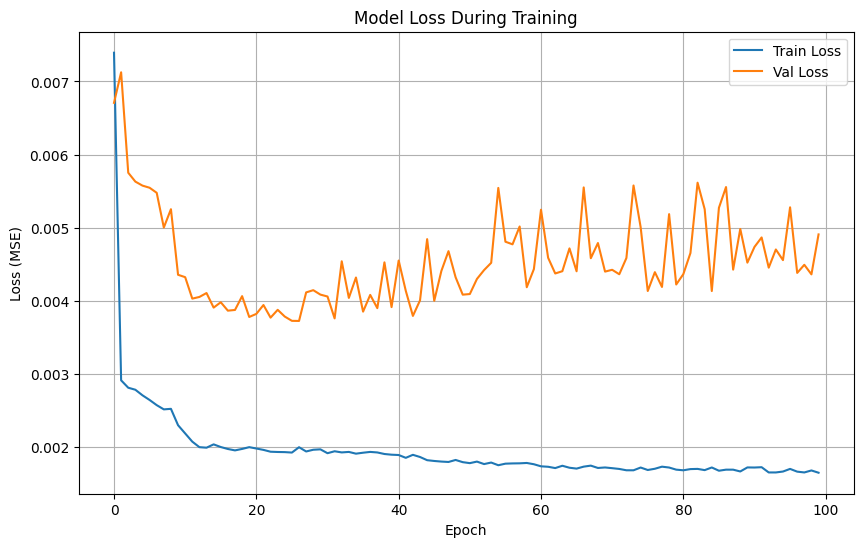

y_true shape: (1083, 1)
y_pred shape: (1083, 1)
y_true sample: [8.31263044e-05 8.25175002e-05 8.19086961e-05 8.12998920e-05
 9.09129403e-05]
y_pred sample: [8.224988e-05 8.165589e-05 8.106265e-05 8.047013e-05 7.987827e-05]

--- Accuracy Report ---

Test Loss (MSE): 0.0022
RMSE : 0.000010
MAE  : 0.000007
R²   : 0.6283

--- Diagnostic Information ---
y_true mean: 0.000089
y_true std:  0.000016
y_pred mean: 0.000086
y_pred std:  0.000014
Correlation: 0.8166

--- 7-Day Future Prediction ---

Predictions for the next 7 days:
Day 1 (2024-04-30): 0.000087
Day 2 (2024-05-01): 0.000093
Day 3 (2024-05-02): 0.000094
Day 4 (2024-05-03): 0.000094
Day 5 (2024-05-04): 0.000092
Day 6 (2024-05-05): 0.000090
Day 7 (2024-05-06): 0.000087


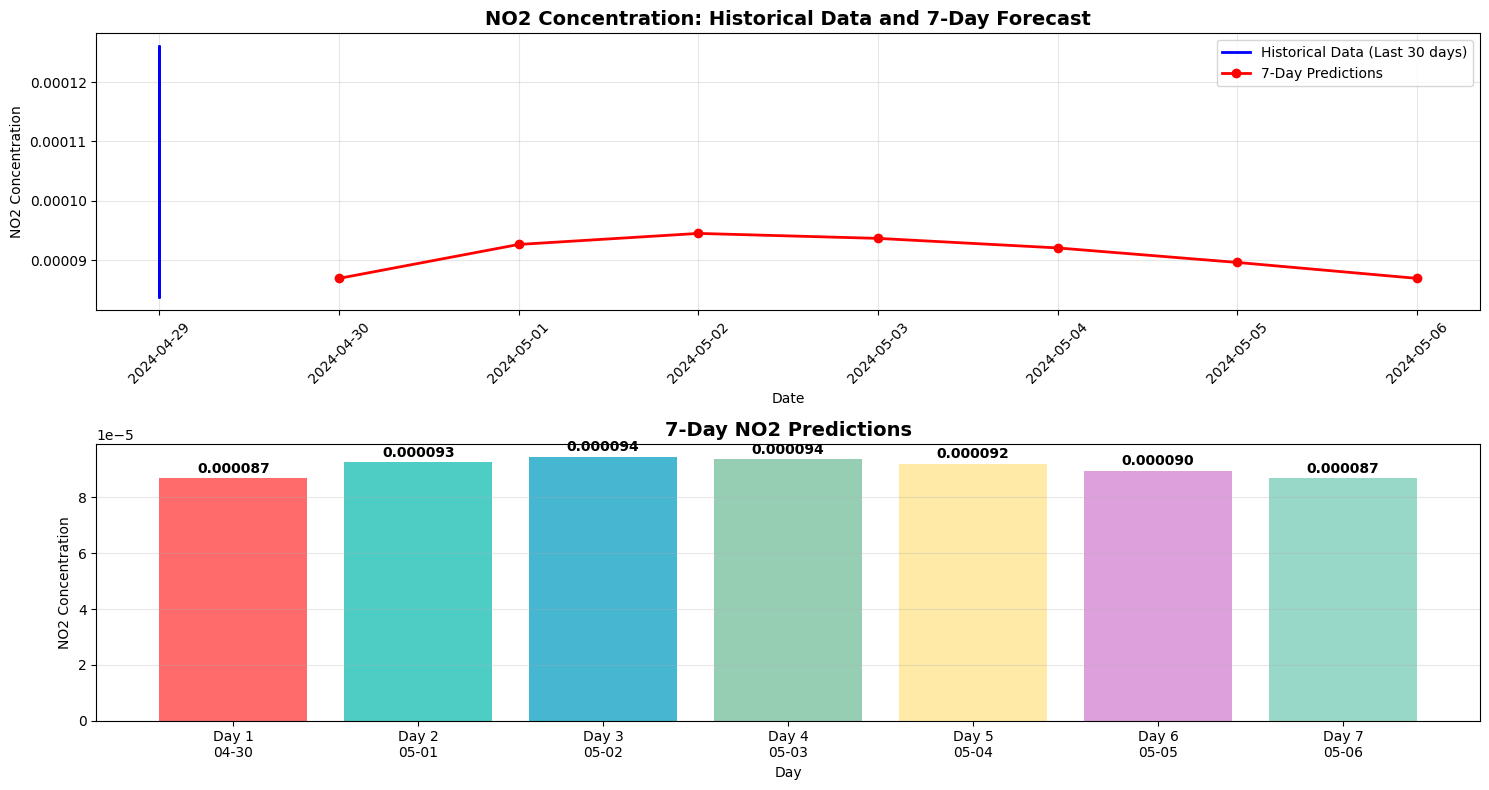

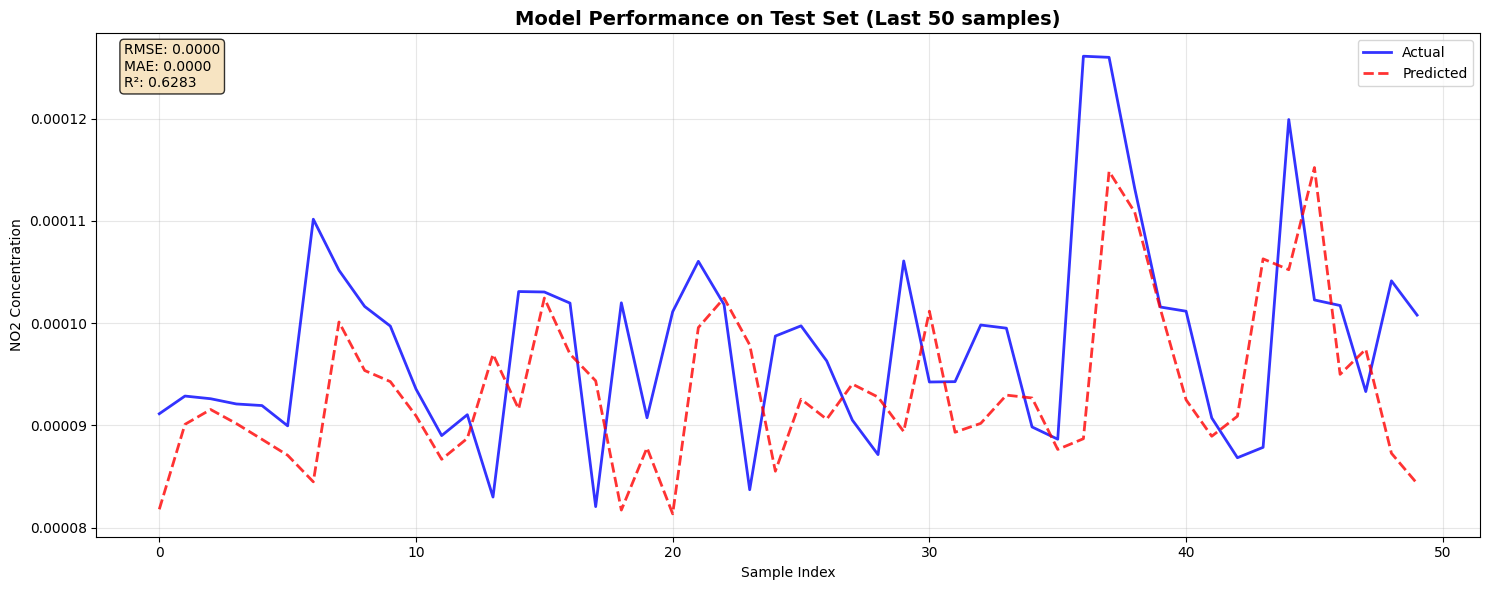


--- Summary ---
Model trained on 4331 samples
Model tested on 1083 samples
Sequence length used: 16 days
Future predictions generated: 7 days
Average predicted value for next 7 days: 0.0001
Min predicted value: 0.0001
Max predicted value: 0.0001


In [ ]:
model = Sequential()
model.add(LSTM(64, # เพิ่มจาก 32 -> 64
               activation="tanh", # เปลี่ยนจาก relu -> tanh
               return_sequences=False, # เพิ่มความชัดเจน
               input_shape=(sequence_length, 1)))
model.add(Dense(32, activation='relu')) # เพิ่ม hidden layer
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse", metrics=['mae'])
model.summary()

history = model.fit(X_train,
                    y_train,
                    epochs=100,    # เพิ่มจาก 50 -> 100
                    batch_size=32, # เพิ่มจาก 16 -> 32
                    validation_split=0.2,
                    verbose=1, # เปลี่ยนเป็น 1 เพื่อดู progress
                    shuffle=True) # เพิ่ม shuffle

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Step 4: Evaluate Model
loss = model.evaluate(X_test, y_test, verbose=0)
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ตรวจสอบข้อมูล
print(f"y_true shape: {y_true.shape}")
print(f"y_pred shape: {y_pred.shape}")
print(f"y_true sample: {y_true[:5].flatten()}")
print(f"y_pred sample: {y_pred[:5].flatten()}")

# แก้ปัญหา format - แปลง loss เป็น scalar ก่อน
if isinstance(loss, list):
    loss = loss[0]  # ใช้ตัวแรกถ้าเป็น list
loss = float(loss)

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae = float(mean_absolute_error(y_true, y_pred))
r2 = float(r2_score(y_true, y_pred))

print("\n--- Accuracy Report ---")
print(f"\nTest Loss (MSE): {loss:.4f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R²   : {r2:.4f}")

# เพิ่มสถิติเพื่อวินิจฉัยปัญหา
print(f"\n--- Diagnostic Information ---")
print(f"y_true mean: {float(np.mean(y_true)):.6f}")
print(f"y_true std:  {float(np.std(y_true)):.6f}")
print(f"y_pred mean: {float(np.mean(y_pred)):.6f}")
print(f"y_pred std:  {float(np.std(y_pred)):.6f}")
print(f"Correlation: {float(np.corrcoef(y_true.flatten(), y_pred.flatten())[0,1]):.4f}")

# =============================================
# เพิ่มส่วนทำนายข้อมูล 7 วันข้างหน้า
# =============================================

def predict_future(model, scaler, data, sequence_length, n_future=7):
    """
    ทำนายข้อมูลในอนาคต

    Parameters:
    - model: LSTM model ที่ train แล้ว
    - scaler: MinMaxScaler ที่ใช้ในการ normalize
    - data: ข้อมูลล่าสุดที่จะใช้เป็นพื้นฐานในการทำนาย
    - sequence_length: ความยาวของลำดับที่ใช้ในการทำนาย
    - n_future: จำนวนวันที่ต้องการทำนายข้างหน้า

    Returns:
    - predictions: array ของค่าทำนายที่ยังไม่ได้ inverse transform
    - predictions_original: array ของค่าทำนายที่ inverse transform แล้ว
    """

    # เตรียมข้อมูลล่าสุดสำหรับการทำนาย
    last_sequence = data[-sequence_length:].reshape(1, sequence_length, 1)

    predictions = []
    current_sequence = last_sequence.copy()

    # ทำนายทีละวัน
    for _ in range(n_future):
        # ทำนายค่าถัดไป
        next_pred = model.predict(current_sequence, verbose=0)
        predictions.append(next_pred[0, 0])

        # อัพเดตลำดับสำหรับการทำนายครั้งต่อไป
        # เลื่อนข้อมูลและใส่ค่าทำนายใหม่เข้าไป
        current_sequence = np.roll(current_sequence, -1, axis=1)
        current_sequence[0, -1, 0] = next_pred[0, 0]

    # แปลงกลับเป็นค่าจริง
    predictions = np.array(predictions).reshape(-1, 1)
    predictions_original = scaler.inverse_transform(predictions)

    return predictions, predictions_original.flatten()

# ทำนาย 7 วันข้างหน้า
print("\n--- 7-Day Future Prediction ---")
future_predictions_scaled, future_predictions = predict_future(
    model, scaler, no2_scaled, sequence_length, n_future=7
)

# สร้างวันที่สำหรับการทำนาย
last_date = df['date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='D')

# แสดงผลการทำนาย
print(f"\nPredictions for the next 7 days:")
for i, (date, pred) in enumerate(zip(future_dates, future_predictions)):
    print(f"Day {i+1} ({date.strftime('%Y-%m-%d')}): {pred:.6f}")

# =============================================
# สร้างกราฟแสดงผลการทำนาย
# =============================================

# เตรียมข้อมูลสำหรับการแสดงกราฟ
# ใช้ข้อมูล 30 วันล่าสุดเพื่อให้เห็นแนวโน้ม
n_display = 30
historical_dates = df['date'].iloc[-n_display:]
historical_values = df['NO2'].iloc[-n_display:]

plt.figure(figsize=(15, 8))

# กราฟข้อมูลประวัติศาสตร์
plt.subplot(2, 1, 1)
plt.plot(historical_dates, historical_values, 'b-', linewidth=2, label='Historical Data (Last 30 days)')
plt.plot(future_dates, future_predictions, 'r-', linewidth=2, marker='o', markersize=6, label='7-Day Predictions')
plt.title('NO2 Concentration: Historical Data and 7-Day Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('NO2 Concentration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# กราฟแสดงเฉพาะการทำนาย
plt.subplot(2, 1, 2)
plt.bar(range(1, 8), future_predictions, color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#ffeaa7', '#dda0dd', '#98d8c8'])
plt.title('7-Day NO2 Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('NO2 Concentration')
plt.xticks(range(1, 8), [f'Day {i}\n{date.strftime("%m-%d")}' for i, date in enumerate(future_dates, 1)])
plt.grid(True, alpha=0.3, axis='y')

# เพิ่มค่าบนแท่งกราฟ
for i, v in enumerate(future_predictions):
    plt.text(i+1, v + max(future_predictions)*0.01, f'{v:.6f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# =============================================
# กราฟเปรียบเทียบข้อมูลจริงกับการทำนายในชุดทดสอบ
# =============================================

plt.figure(figsize=(15, 6))

# แสดงผลการทำนายในชุดทดสอบ (เฉพาะ 50 ตัวอย่างสุดท้าย)
n_show = min(50, len(y_true))
plt.plot(range(n_show), y_true[-n_show:], 'b-', linewidth=2, label='Actual', alpha=0.8)
plt.plot(range(n_show), y_pred[-n_show:], 'r--', linewidth=2, label='Predicted', alpha=0.8)

plt.title('Model Performance on Test Set (Last 50 samples)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('NO2 Concentration')
plt.legend()
plt.grid(True, alpha=0.3)

# เพิ่มสถิติบนกราฟ
plt.text(0.02, 0.98, f'RMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n--- Summary ---")
print(f"Model trained on {len(X_train)} samples")
print(f"Model tested on {len(X_test)} samples")
print(f"Sequence length used: {sequence_length} days")
print(f"Future predictions generated: 7 days")
print(f"Average predicted value for next 7 days: {np.mean(future_predictions):.4f}")
print(f"Min predicted value: {np.min(future_predictions):.4f}")
print(f"Max predicted value: {np.max(future_predictions):.4f}")

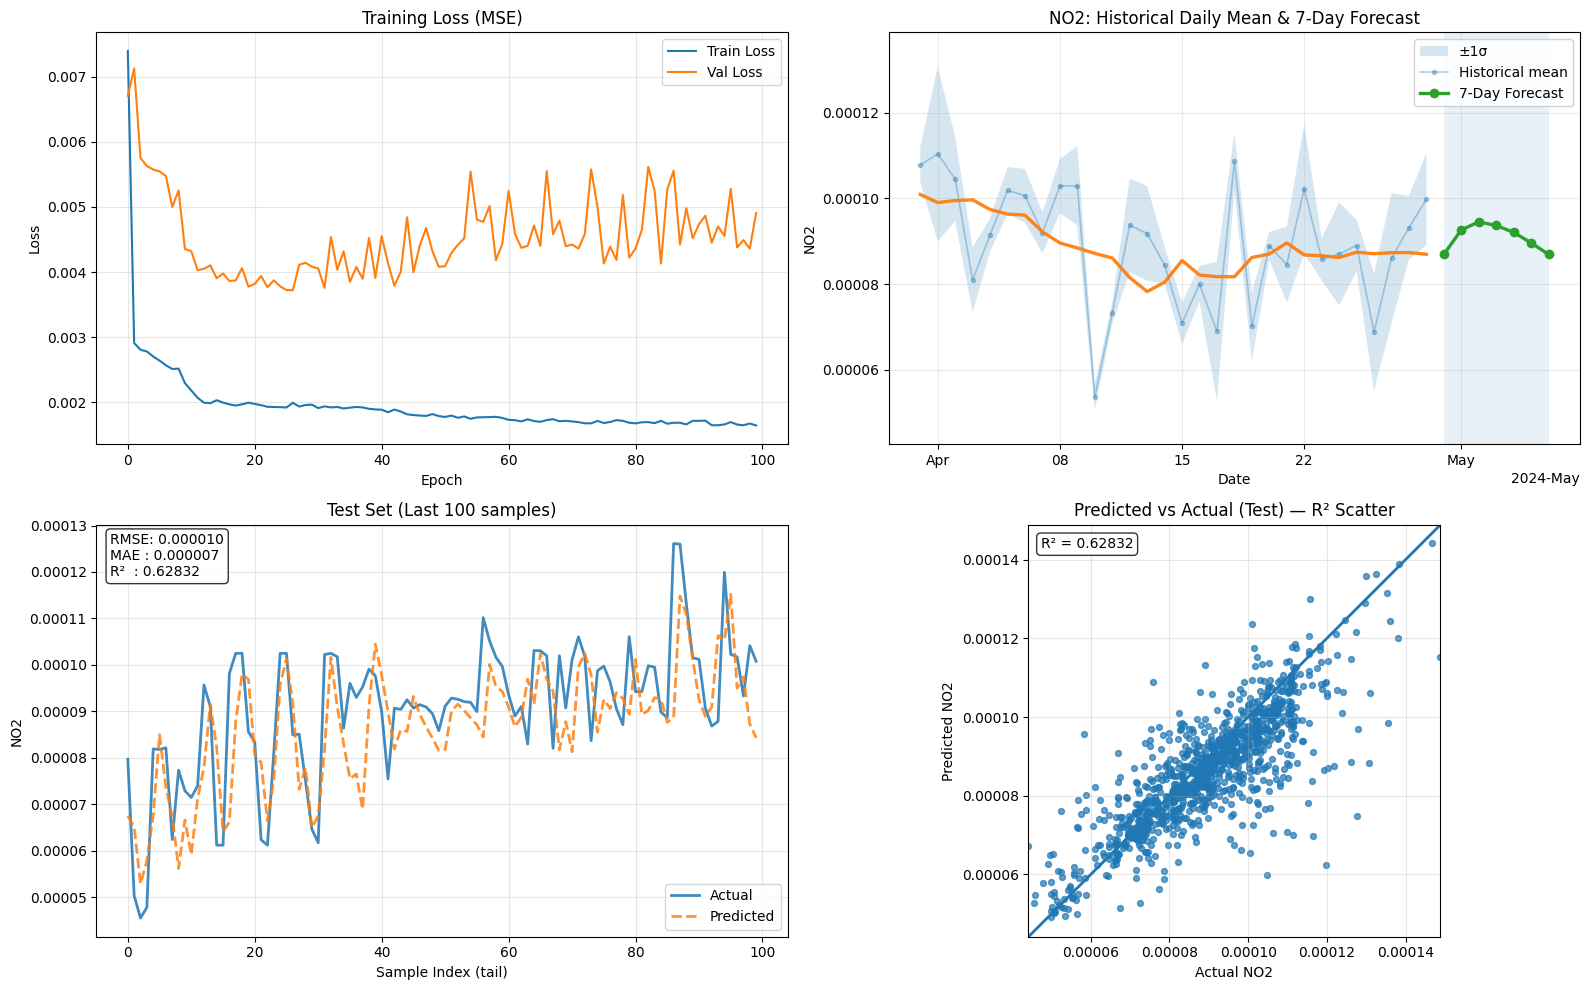

In [ ]:
# ======== FORCE SHOW 4 SUBPLOTS (2x2) ========
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# ---------- sensible defaults / fallbacks ----------
HIST_DAYS       = globals().get('HIST_DAYS', 30)        # แสดงประวัติย้อนหลัง
N_SHOW_TEST     = globals().get('N_SHOW_TEST', 100)     # จำนวนจุดท้ายสุดฝั่ง test
history         = globals().get('history', None)        # Keras History หรือ None
future_predictions = globals().get('future_predictions', [])
future_dates    = globals().get('future_dates', [])
rmse = float(globals().get('rmse', np.nan))
mae  = float(globals().get('mae',  np.nan))
r2   = float(globals().get('r2',   np.nan))

# ---------- 1) เตรียม historical: daily mean ±1σ ----------
df_plot = df[['date', 'NO2']].copy()
df_plot['date'] = pd.to_datetime(df_plot['date'])
df_plot = df_plot.sort_values('date')

daily_stats = (
    df_plot.groupby('date', as_index=False)['NO2']
           .agg(mean='mean', std='std')
           .sort_values('date')
)
daily_stats['std']   = daily_stats['std'].fillna(0.0)
daily_stats['lower'] = daily_stats['mean'] - daily_stats['std']
daily_stats['upper'] = daily_stats['mean'] + daily_stats['std']

# เลือกช่วงท้ายตาม HIST_DAYS
hist_src = daily_stats.tail(HIST_DAYS if len(daily_stats) >= HIST_DAYS else len(daily_stats))

# ---------- 2) เตรียมข้อมูล test สำหรับกราฟล่างซ้าย ----------
y_true = np.asarray(globals().get('y_true', np.array([]))).flatten()
y_pred = np.asarray(globals().get('y_pred', np.array([]))).flatten()
n_pair = min(len(y_true), len(y_pred))
n_show = min(N_SHOW_TEST, n_pair)
x_idx  = np.arange(n_show)

# ---------- 3) สร้างรูป 2x2 ----------
plt.close('all')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
(ax11, ax12), (ax21, ax22) = axes

# (1) Training/Validation Loss
train_loss = history.history.get("loss", []) if hasattr(history, 'history') else []
val_loss   = history.history.get("val_loss", []) if hasattr(history, 'history') else []
ax11.plot(train_loss, label="Train Loss")
ax11.plot(val_loss,   label="Val Loss")
ax11.set_title("Training Loss (MSE)")
ax11.set_xlabel("Epoch")
ax11.set_ylabel("Loss")
ax11.grid(True, alpha=0.3)
ax11.legend()

# (2) Historical daily mean ±1σ + 7-day Forecast — สวยงาม, ไม่มีคำว่า "smooth" ใน legend
_hist = hist_src.copy().sort_values('date').reset_index(drop=True)
if not _hist.empty:
    SMOOTH_WIN = 7 if len(_hist) >= 7 else max(1, len(_hist)//2*2+1)  # หน้าต่างเลขคี่
    _hist['mean_smooth'] = _hist['mean'].rolling(window=SMOOTH_WIN, center=True, min_periods=1).mean()

    # แถบ ±1σ โปร่ง
    ax12.fill_between(_hist['date'], _hist['lower'], _hist['upper'], alpha=0.18, label='±1σ')

    # จุด/เส้นดิบจาง ๆ
    ax12.plot(_hist['date'], _hist['mean'], linewidth=1.2, alpha=0.35,
              marker='o', markersize=3, linestyle='-', label='Historical mean')

    # เส้นเนียน (ไม่มี label → ไม่ขึ้นใน legend)
    ax12.plot(_hist['date'], _hist['mean_smooth'], linewidth=2.4, alpha=0.95)
else:
    ax12.text(0.5, 0.5, 'No historical data', ha='center', va='center', transform=ax12.transAxes)

# พยากรณ์ + ไฮไลต์ช่วง forecast
if len(future_predictions) > 0:
    fdates = pd.to_datetime(pd.Index(future_dates))
    ax12.plot(fdates, future_predictions, linewidth=2.4, marker='o', label='7-Day Forecast')
    if not _hist.empty:
        ax12.axvspan(fdates.min(), fdates.max(), alpha=0.10)

# ฟอร์แมตแกน/รายละเอียด (แกน Y แสดงค่าตรง ๆ ไม่เป็น *10^-4)
ax12.set_title('NO2: Historical Daily Mean & 7-Day Forecast')
ax12.set_xlabel('Date'); ax12.set_ylabel('NO2')
locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
ax12.xaxis.set_major_locator(locator)
ax12.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax12.ticklabel_format(style='plain', axis='y')  # <-- แสดงหน่วยเดิม
ax12.grid(True, alpha=0.25)
ax12.legend(loc='upper right', framealpha=0.9)

# ปรับ Y-limits ให้มี padding จากข้อมูล history + forecast
vals = []
if not _hist.empty:
    vals += _hist['lower'].tolist() + _hist['upper'].tolist() + _hist['mean'].tolist()
if len(future_predictions) > 0:
    vals += list(np.asarray(future_predictions, dtype=float))
if len(vals) > 0:
    lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
    pad = (hi - lo) * 0.10 if hi > lo else (abs(hi) if hi != 0 else 1.0) * 0.10
    ax12.set_ylim(lo - pad, hi + pad)

# (3) Test set (tail) Actual vs Predicted
if n_show > 0:
    ax21.plot(x_idx, y_true[-n_show:], linewidth=2, label='Actual', alpha=0.85)
    ax21.plot(x_idx, y_pred[-n_show:], linestyle='--', linewidth=2, label='Predicted', alpha=0.85)
else:
    ax21.text(0.5, 0.5, 'No test samples', ha='center', va='center', transform=ax21.transAxes)

ax21.set_title(f'Test Set (Last {n_show} samples)')
ax21.set_xlabel('Sample Index (tail)'); ax21.set_ylabel('NO2')
ax21.ticklabel_format(style='plain', axis='y')  # <-- แสดงหน่วยเดิม
ax21.grid(True, alpha=0.3); ax21.legend()
ax21.text(0.02, 0.98, f'RMSE: {rmse:.6f}\nMAE : {mae:.6f}\nR²  : {r2:.5f}',
          transform=ax21.transAxes, va='top',
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# (4) R² Scatter: Pred vs Actual + y=x
if n_pair > 0:
    ax22.scatter(y_true, y_pred, s=18, alpha=0.7)
    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    if lo == hi:
        lo -= 1.0; hi += 1.0
    ax22.plot([lo, hi], [lo, hi], linewidth=2)
    ax22.set_xlim(lo, hi); ax22.set_ylim(lo, hi)
    ax22.set_aspect('equal', adjustable='box')
else:
    ax22.text(0.5, 0.5, 'No points', ha='center', va='center', transform=ax22.transAxes)

ax22.set_title('Predicted vs Actual (Test) — R² Scatter')
ax22.set_xlabel('Actual NO2'); ax22.set_ylabel('Predicted NO2')
ax22.ticklabel_format(style='plain', axis='y')  # <-- แสดงหน่วยเดิม
ax22.grid(True, alpha=0.3)
ax22.text(0.03, 0.97, f'R² = {r2:.5f}', transform=ax22.transAxes, va='top',
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


In [ ]:
# =============================================
# บันทึกโมเดลและ Scaler สำหรับใช้ต่อ (NO2 Model)
# =============================================

import joblib
import pickle
from datetime import datetime

# สร้างชื่อไฟล์ตาม timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. บันทึก Keras Model สำหรับ NO2
model_path = f"/content/drive/My Drive/USE_NO2_CO/lstm_no2_model_{timestamp}.h5"
model.save(model_path)
print(f"\n✅ NO2 Model saved to: {model_path}")

# 2. บันทึก Scaler สำหรับ NO2
scaler_path = f"/content/drive/My Drive/USE_NO2_CO/no2_scaler_{timestamp}.pkl"
joblib.dump(scaler, scaler_path)
print(f"✅ NO2 Scaler saved to: {scaler_path}")

# 3. บันทึก Model Configuration สำหรับ NO2
config = {
    'target_variable': 'NO2',
    'sequence_length': sequence_length,
    'scaler_range': (scaler.data_min_[0], scaler.data_max_[0]),
    'model_architecture': {
        'lstm_units': 64,
        'dense_units': 32,
        'input_shape': (sequence_length, 1)
    },
    'training_params': {
        'epochs': 100,
        'batch_size': 32,
        'validation_split': 0.2
    },
    'performance': {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'test_loss': loss
    },
    'data_info': {
        'original_no2_min': float(df['NO2'].min()),
        'original_no2_max': float(df['NO2'].max()),
        'data_points': len(df),
        'training_samples': len(X_train),
        'test_samples': len(X_test)
    }
}

config_path = f"/content/drive/My Drive/USE_NO2_CO/no2_model_config_30urban{timestamp}.pkl"
with open(config_path, 'wb') as f:
    pickle.dump(config, f)
print(f"✅ NO2 Configuration saved to: {config_path}")

# =============================================
# ตัวอย่างการโหลดและใช้โมเดล NO2 ใหม่
# =============================================

print(f"\n{'='*50}")
print("📋 HOW TO USE THE SAVED NO2 MODEL:")
print(f"{'='*50}")



✅ NO2 Model saved to: /content/drive/My Drive/USE_NO2_CO/lstm_no2_model_20250911_061545.h5
✅ NO2 Scaler saved to: /content/drive/My Drive/USE_NO2_CO/no2_scaler_20250911_061545.pkl
✅ NO2 Configuration saved to: /content/drive/My Drive/USE_NO2_CO/no2_model_config_30urban20250911_061545.pkl

📋 HOW TO USE THE SAVED NO2 MODEL:


In [ ]:
# ========================================
# Load saved model & components (Keras 3 safe)
# ========================================
import numpy as np
import pandas as pd
import joblib, pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model
# from sklearn.preprocessing import MinMaxScaler  # not needed here

# --- paths you already have defined ---
# model_path = ...
# scaler_path = ...
# config_path = ...

# 1) Load model WITHOUT compiling; then compile with explicit objects
model = load_model(model_path, compile=False)
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.MeanAbsoluteError()],
)

# 2) Load scaler + config
scaler = joblib.load(scaler_path)
with open(config_path, 'rb') as f:
    config = pickle.load(f)

sequence_length = config['sequence_length']
print("Model loaded successfully!")
print(f"Sequence length: {sequence_length}")
if 'performance' in config and 'r2' in config['performance']:
    print(f"Model performance - R²: {config['performance']['r2']:.4f}")

# ========================================
# Prediction helpers
# ========================================
def predict_new_data(new_data, model, scaler, sequence_length):
    """
    Predict next-day value from the latest sequence_length values in new_data.
    """
    if len(new_data) < sequence_length:
        raise ValueError(f"Need at least {sequence_length} data points, got {len(new_data)}")

    recent_data = np.asarray(new_data[-sequence_length:], dtype=float)
    scaled = scaler.transform(recent_data.reshape(-1, 1))
    X_new = scaled.reshape(1, sequence_length, 1)

    pred_scaled = model.predict(X_new, verbose=0)
    pred = scaler.inverse_transform(pred_scaled)
    return float(pred[0, 0])

def predict_future_days(recent_data, model, scaler, sequence_length, n_days=7):
    """
    Iteratively predict n_days into the future (uses own predictions).
    """
    preds = []
    cur = np.asarray(recent_data, dtype=float).copy()
    for _ in range(n_days):
        nxt = predict_new_data(cur, model, scaler, sequence_length)
        preds.append(float(nxt))
        cur = np.append(cur[-sequence_length+1:], nxt)
    return preds

# ========================================
# Example usage (toy data)
# ========================================
sample_data = np.array([
    25.5, 28.2, 31.1, 29.8, 26.7, 24.3, 27.9,
    30.2, 28.5, 25.8, 29.1, 31.7, 28.9, 26.4,
    25.1, 27.6, 30.3, 29.5
], dtype=float)

if len(sample_data) >= sequence_length:
    tomorrow = predict_new_data(sample_data, model, scaler, sequence_length)
    print(f"Tomorrow's NO2 prediction: {tomorrow:.4f}")

    week_predictions = predict_future_days(sample_data, model, scaler, sequence_length, n_days=7)
    print("Next 7 days predictions:")
    for i, pred in enumerate(week_predictions, 1):
        print(f"  Day {i}: {pred:.6f}")

# ========================================
# Testing with your real dataframe (define df before this!)
# ========================================
# Ensure df exists; e.g.:
# df = pd.read_csv("/content/drive/My Drive/hex_NO2_CO/NO2_urban.csv", parse_dates=["date"])
# assert "NO2" in df.columns, "df must contain a 'NO2' column"

if 'df' in globals():
    latest_data = df['NO2'].values[-sequence_length:]
    if len(latest_data) >= sequence_length:
        scaled_latest = scaler.transform(latest_data.reshape(-1, 1))
        X_test_latest = scaled_latest.reshape(1, sequence_length, 1)

        next_day_pred_scaled = model.predict(X_test_latest, verbose=0)
        next_day_pred = scaler.inverse_transform(next_day_pred_scaled).ravel()[0]

        print(f"Last {sequence_length} days average: {np.mean(latest_data):.6f}")
        print(f"Next day prediction: {next_day_pred:.6f}")
        print(f"Change from average: {next_day_pred - np.mean(latest_data):+.6f}")

print("\n✅ Model is ready to use! ")


Model loaded successfully!
Sequence length: 16
Model performance - R²: 0.6283
Tomorrow's NO2 prediction: 0.0005
Next 7 days predictions:
  Day 1: 0.000528
  Day 2: 0.000189
  Day 3: 0.000234
  Day 4: 0.000295
  Day 5: 0.000292
  Day 6: 0.000314
  Day 7: 0.000316
Last 16 days average: 0.000102
Next day prediction: 0.000087
Change from average: -0.000015

✅ Model is ready to use! 


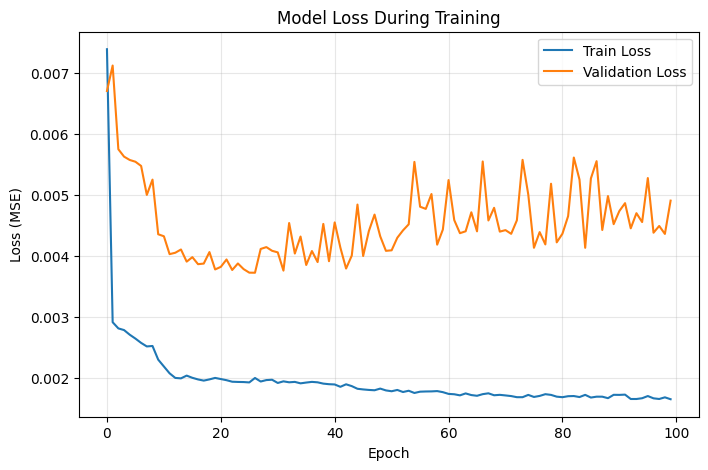


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00001
R²   : -0.206


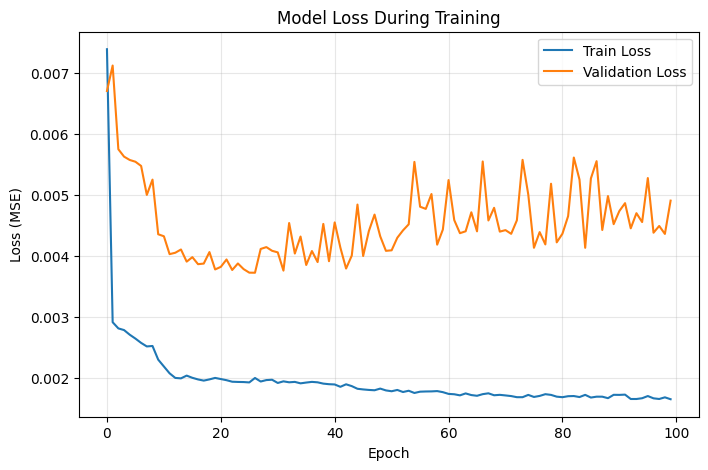


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00001
R²   : -0.008


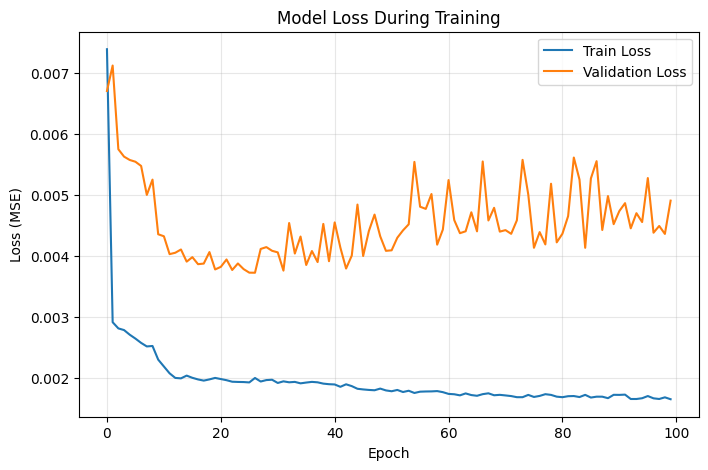


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.465


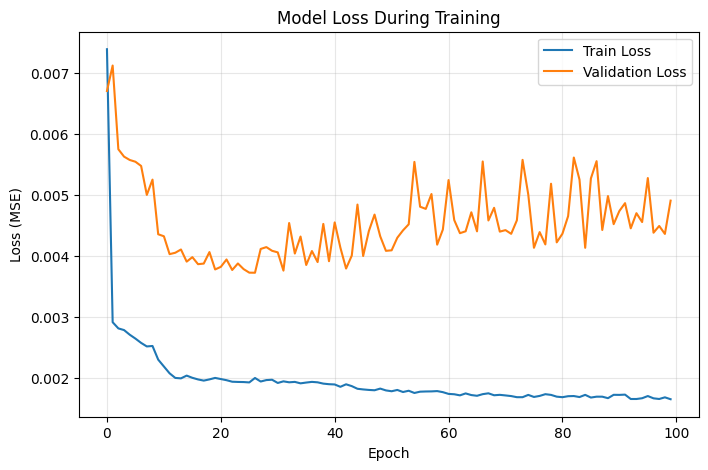


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00001
R²   : -0.053


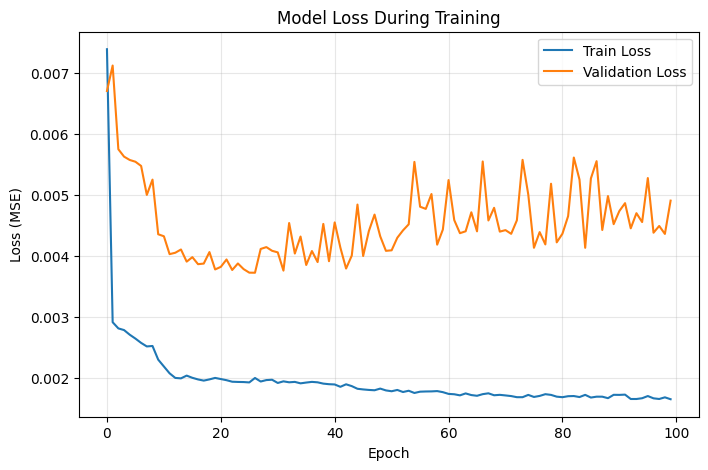


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.084


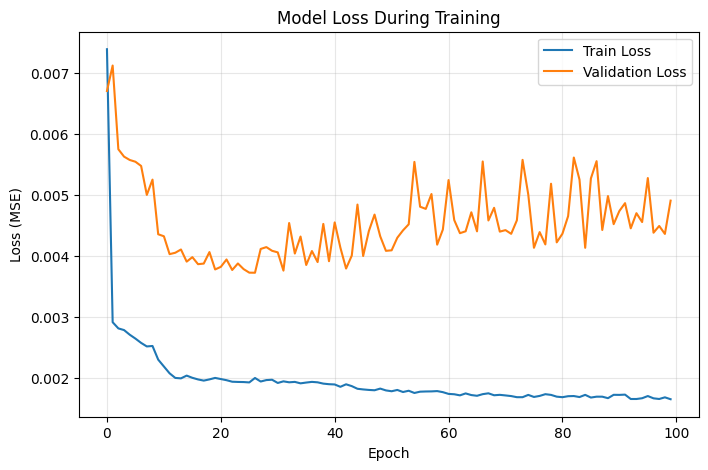


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.096


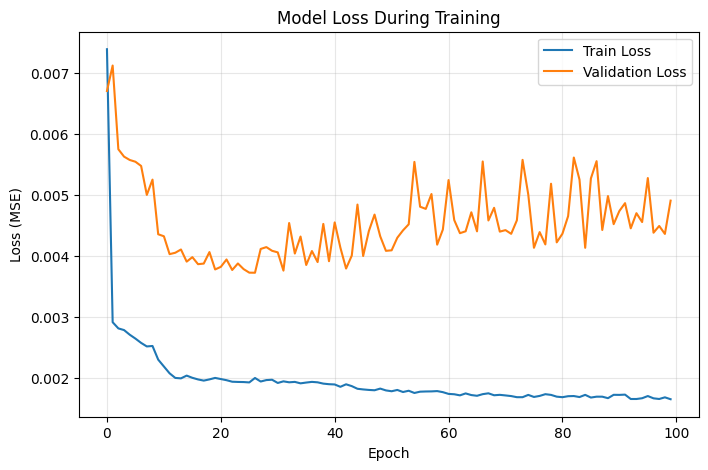


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.018


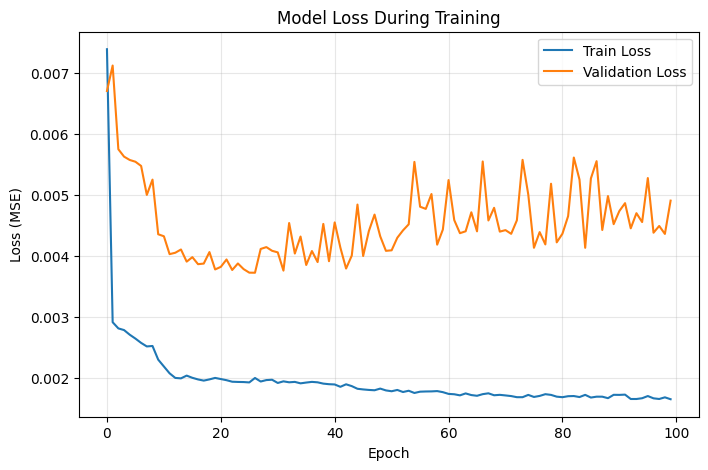


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.196


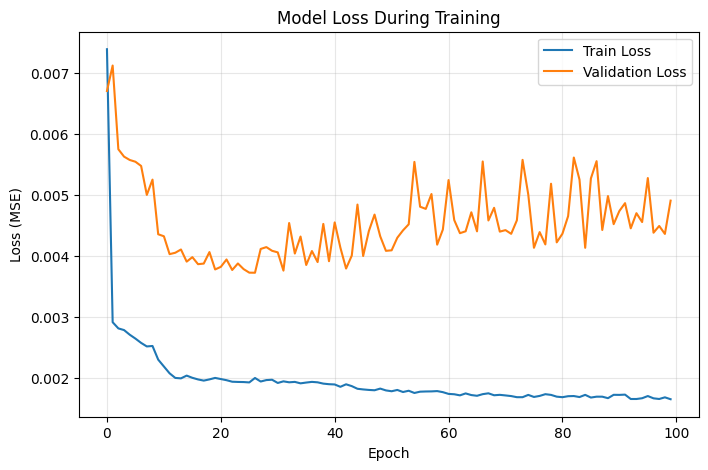


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00001
R²   : -0.049


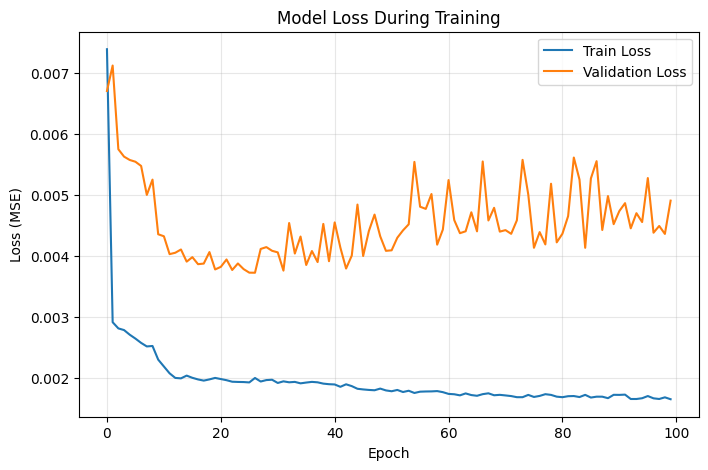


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.122


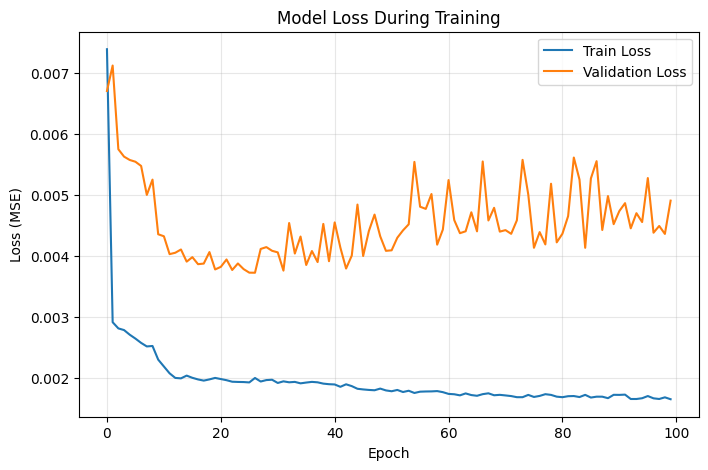


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.116


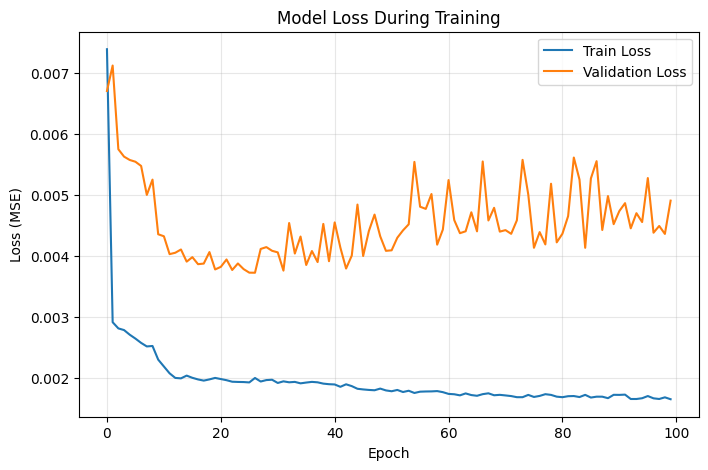


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.091


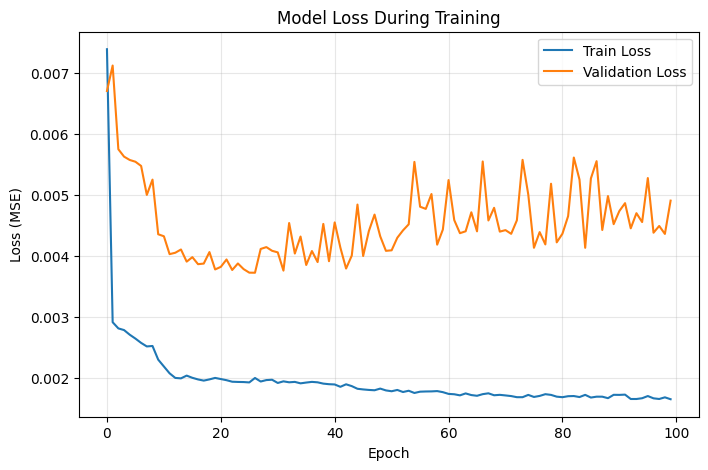


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.071


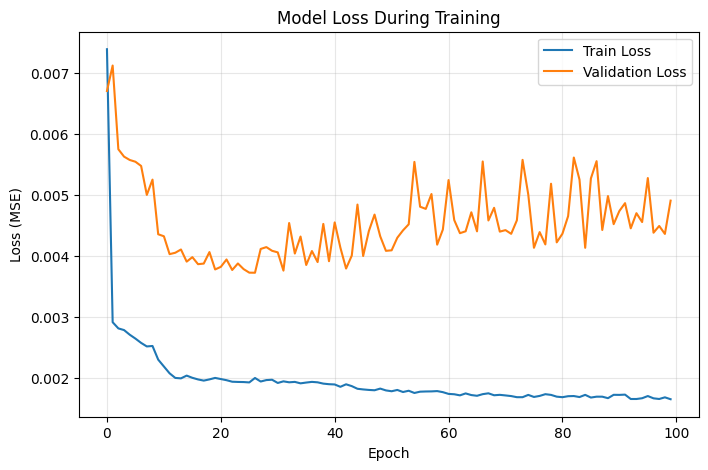


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.173


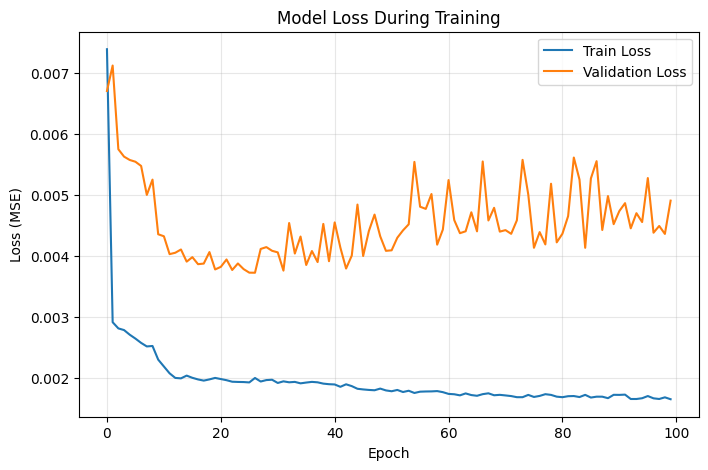


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.300


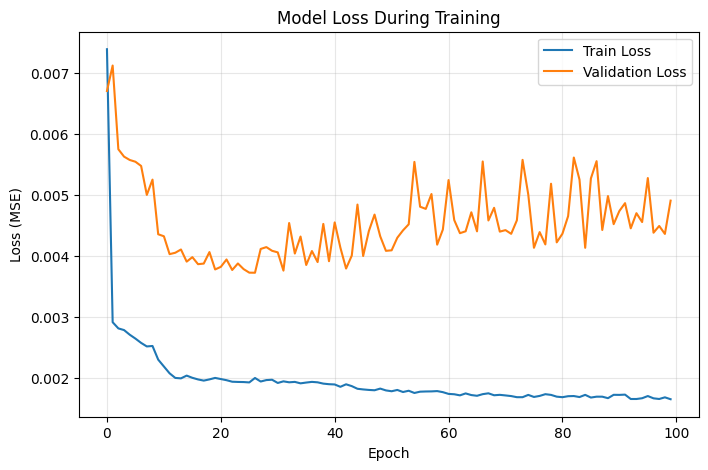


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00001
R²   : -0.052


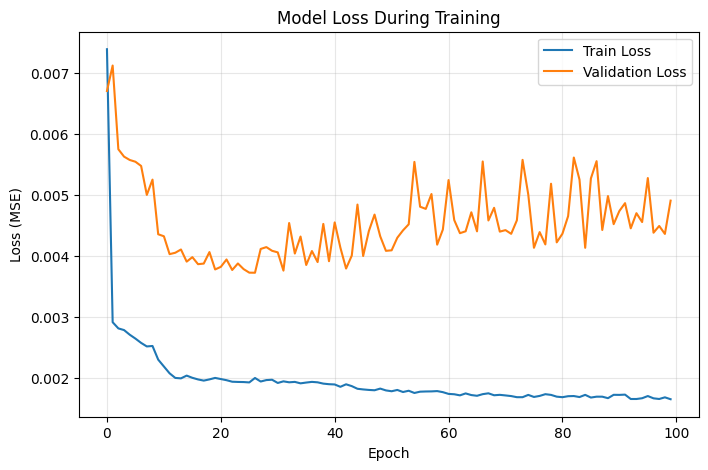


--- Model Evaluation ---
MAE  : 0.00002
RMSE : 0.00002
R²   : -0.171


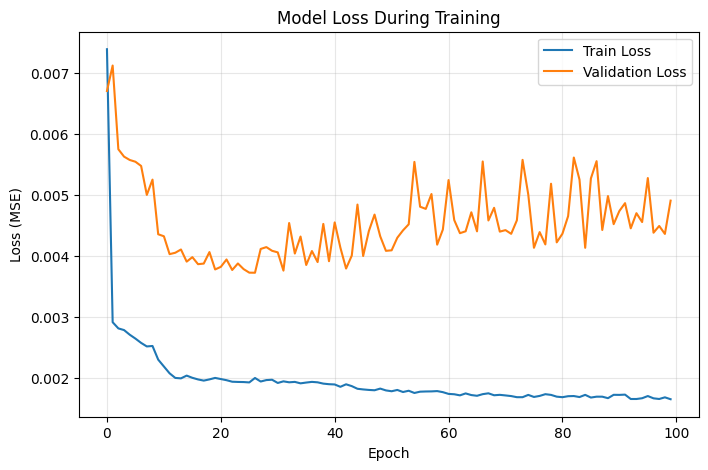


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.161


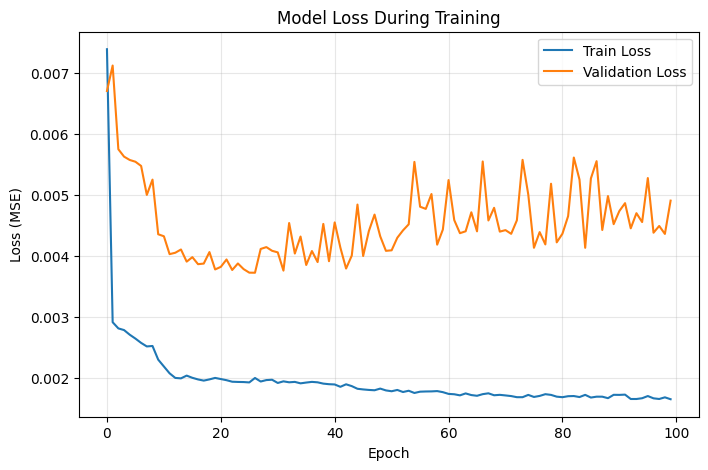


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.134


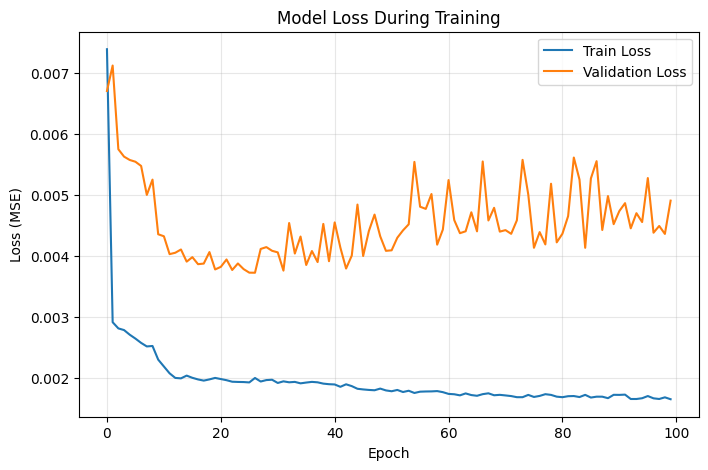


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.060


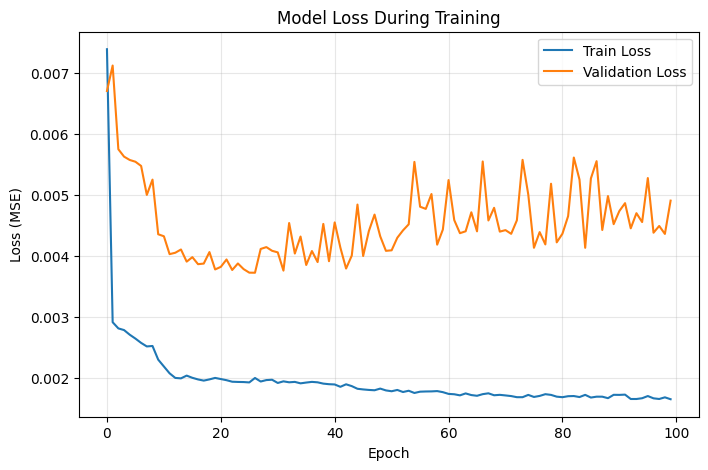


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.161


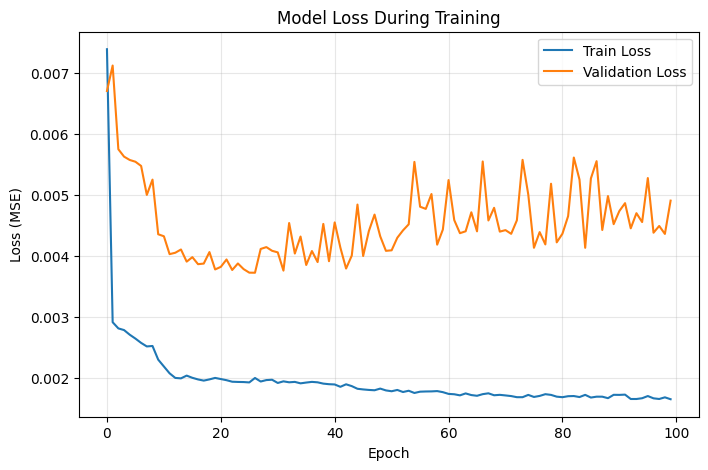


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.236


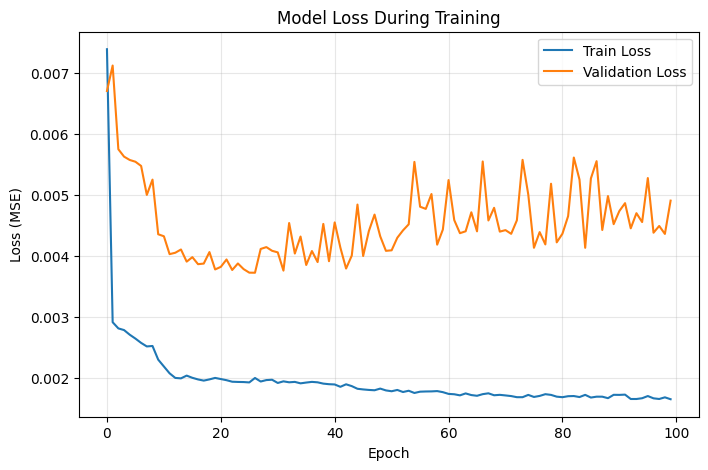


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00001
R²   : -0.092


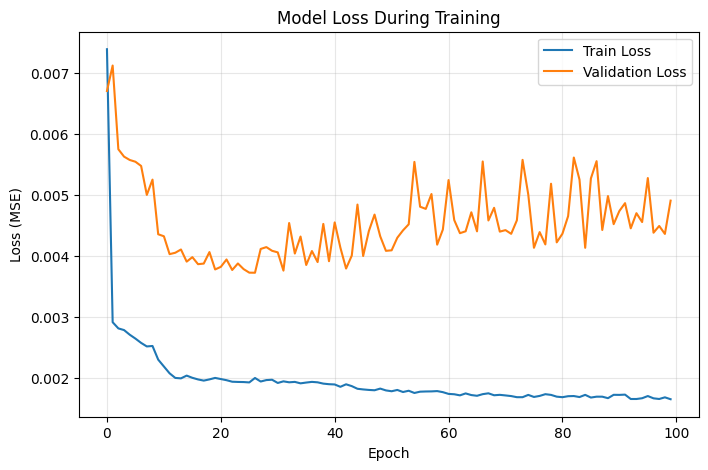


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00001
R²   : -0.051


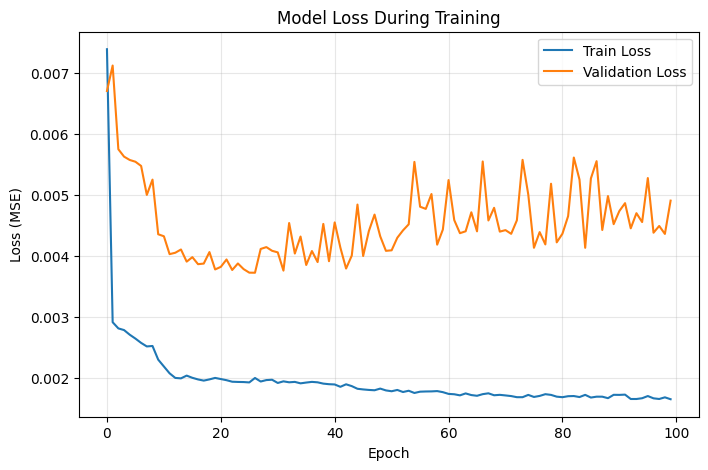


--- Model Evaluation ---
MAE  : 0.00002
RMSE : 0.00002
R²   : -0.180


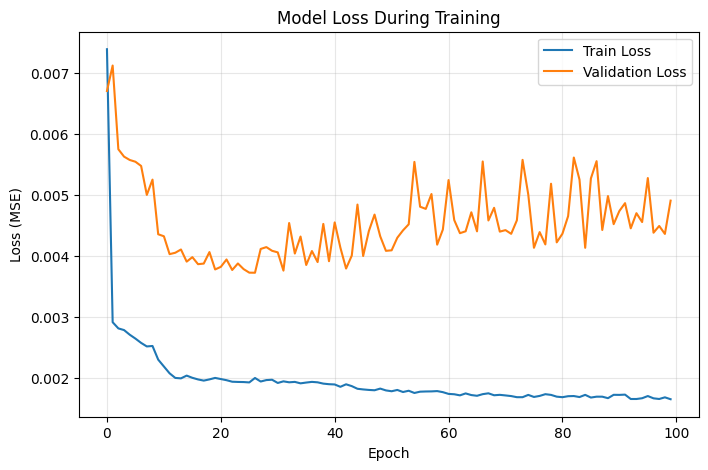


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.153


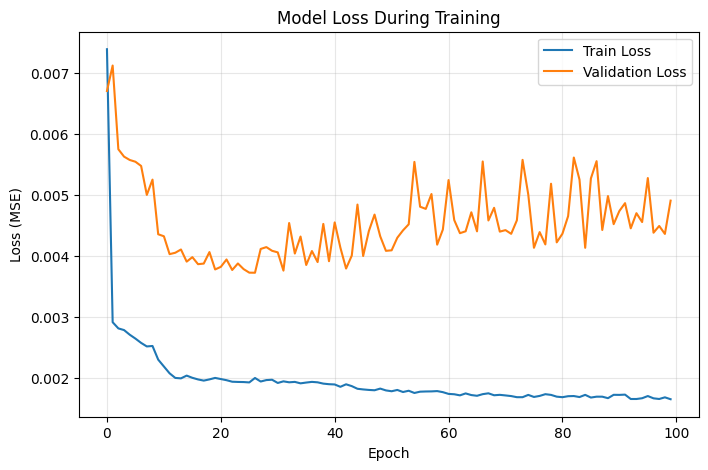


--- Model Evaluation ---
MAE  : 0.00001
RMSE : 0.00002
R²   : -0.224


In [ ]:
# ==== Libraries ====
import numpy as np
import pandas as pd
from tensorflow.keras import Input
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ==== Config ====
CSV_PATH = "/content/drive/My Drive/hex_NO2_CO/NO2_hex30_urban.csv"   # ใช้ไฟล์ที่แนบ
SEQ_LEN  = 16                                # ความยาวหน้าต่างอินพุต
N_FUTURE = 7                                # จำนวนวันที่ต้องการพยากรณ์
TEST_RATIO = 0.2                             # สัดส่วน test ช่วงท้าย

# ==== 1) Load & basic clean ====
df = pd.read_csv(CSV_PATH, parse_dates=["date"])
df["NO2"] = df["NO2"].interpolate(method='linear')  # interpolation สำหรับค่ากลาง
df["NO2"] = df["NO2"].bfill()  # backward fill สำหรับค่าแรก
df["NO2"] = df["NO2"].ffill()  # forward fill สำหรับค่าสุดท้าย

# ถ้ามีหลายแถวต่อ id+date ให้รวมเป็นค่าเฉลี่ยต่อวัน
if df.duplicated(subset=["id","date"]).any():
    df = (df.groupby(["id","date"], as_index=False)["NO2"].mean())

# เรียงตามเวลา
df = df.sort_values(["id","date"])

# ==== helpers ====
def make_daily_complete(group: pd.DataFrame, id_col='id'):
    """ เติมวันให้ต่อเนื่องระดับรายวัน ต่อ id และจัดการค่าว่าง """
    gid = group[id_col].iloc[0]
    g = group.sort_values("date").reset_index(drop=True)
    full_idx = pd.date_range(g["date"].min(), g["date"].max(), freq="D")
    g = (g.set_index("date")
          .reindex(full_idx)
          .rename_axis("date")
          .reset_index())
    g[id_col] = gid
    # ทำความสะอาด: interpolate → bfill → ffill
    g["NO2"] = g["NO2"].interpolate("linear").bfill().ffill()
    return g[["id","date","NO2"]]

def create_sequences(arr, seq_len):
    X = np.array([arr[i-seq_len:i] for i in range(seq_len, len(arr))])
    y = np.array([arr[i] for i in range(seq_len, len(arr))])
    return X, y

def build_model1(seq_len):
    model = Sequential([
        Input(shape=(seq_len, 1)),
        LSTM(64, activation="tanh"),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

def build_model(seq_len):
    model = Sequential([
        Input(shape=(seq_len, 1)),
        LSTM(64, activation="tanh", return_sequences=True),  # ✅ LSTM ชั้นแรก ให้ return_sequences=True
        Dropout(0.2),                                        # ✅ dropout กัน overfitting
        LSTM(32, activation="tanh"),                         # ✅ LSTM ชั้นสอง
        Dense(64, activation="relu"),                        # ✅ Dense ซ่อนเพิ่ม
        Dense(32, activation="relu"),
        Dense(1)                                             # output
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

def predict_future_recursive(model, scaler, data_scaled, seq_len, n_future):
    """ ใช้ลำดับล่าสุด (seq_len วันท้ายสุด) แล้วพยากรณ์ทีละวันแบบ recursive """
    last_seq = data_scaled[-seq_len:].reshape(1, seq_len, 1)
    preds_scaled = []
    cur = last_seq.copy()
    for _ in range(n_future):
        nxt = model.predict(cur, verbose=0)
        preds_scaled.append(nxt[0,0])
        # shift window
        cur = np.roll(cur, -1, axis=1)
        cur[0, -1, 0] = nxt[0,0]
    preds_scaled = np.array(preds_scaled).reshape(-1,1)
    return scaler.inverse_transform(preds_scaled).flatten()

# ==== 2) Train & Forecast per id ====
all_forecasts = []  # จะเก็บผลรวมทุก id

for gid, g in df.groupby("id"):
    # ทำให้ daily ต่อเนื่อง + เติมค่าว่าง
    g_daily = make_daily_complete(g)

    # เตรียมสเกล (fit ด้วยช่วง train เพื่อเลี่ยง leakage)
    values = g_daily["NO2"].values.reshape(-1,1)

    # แบ่ง train/test ตามเวลา (ไม่สับลำดับ)
    n = len(values)
    n_test = max(1, int(n * TEST_RATIO))
    n_train = n - n_test
    train_vals = values[:n_train]
    test_vals  = values[n_train:]

    # ถ้าข้อมูลน้อยเกินไป ข้าม id นี้
    if n_train <= SEQ_LEN or n <= (SEQ_LEN + 1):
        print(f"[Skip id={gid}] data too short (n={n}) for SEQ_LEN={SEQ_LEN}")
        continue

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_vals)
    full_scaled  = np.vstack([train_scaled, scaler.transform(test_vals)])  # transform ส่วน test ตาม scaler เดิม

    # สร้างลำดับจาก 'full_scaled' แล้วตัด train/test ด้วยดัชนี
    X_full, y_full = create_sequences(full_scaled, SEQ_LEN)
    # ดัชนีที่แบ่งหลังสร้างลำดับ
    split_idx = n_train - SEQ_LEN
    X_train, y_train = X_full[:split_idx], y_full[:split_idx]
    X_test,  y_test  = X_full[split_idx:],  y_full[split_idx:]

    # reshape เป็น (batch, timesteps, features)
    X_train = X_train.reshape(-1, SEQ_LEN, 1)
    X_test  = X_test.reshape(-1,  SEQ_LEN, 1)

    # สร้างและเทรนโมเดล
    model = build_model(SEQ_LEN)
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=0)
    ]
    model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        shuffle=False,            # สำคัญสำหรับ time series
        verbose=0,
        callbacks=callbacks
    )

    # ==== แสดง loss curve ====
    plt.figure(figsize=(8,5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("Model Loss During Training")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print("\n--- Model Evaluation ---")
    print(f"MAE  : {mae:.5f}")
    print(f"RMSE : {rmse:.5f}")
    print(f"R²   : {r2:.3f}")

    # พยากรณ์ล่วงหน้า 16 วันต่อจากวันสุดท้ายในซีรีส์ของ id นี้
    future_vals = predict_future_recursive(model, scaler, full_scaled, SEQ_LEN, N_FUTURE)
    start_date = g_daily["date"].iloc[-1] + pd.Timedelta(days=1)
    future_dates = pd.date_range(start=start_date, periods=N_FUTURE, freq="D")

    # เก็บผล
    out = pd.DataFrame({
        "id": gid,
        "date": future_dates,
        "NO2_pred": future_vals
    })
    all_forecasts.append(out)

# ==== 3) Concatenate & Save ====
if all_forecasts:
    result = pd.concat(all_forecasts, ignore_index=True)
    # บันทึกผลรวมทุก id เป็น CSV
    result.to_csv("NO2_forecast_16d_by_id.csv", index=False)
    print("\nSaved: NO2_forecast_16d_by_id.csv")
    # แสดงหัวตาราง
    print(result.head(12))
else:
    print("No forecasts produced (data too short for all ids?).")
